## Load & Read Data

In [1]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# import library
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Helper Method for Database Query

In [2]:
DB_PATH = "ecommerce_hackathon.db"

def get_table(table_name):
    conn = sqlite3.connect(DB_PATH)
    try:
        return pd.read_sql_query(
            f'SELECT * FROM "{table_name}"',
            conn
        )
    finally:
        conn.close()


In [3]:
audit = []
def log_issue(table, issue, count, action, reason):
    audit.append({
        "table": table,
        "issue": issue,
        "records_affected": int(count),
        "action": action,
        "reason": reason
    })

#### Print Customers

In [4]:
customers = get_table("customers")
print(customers)

      customer_id  customer_name   age  gender        city signup_date  \
0               1    Hassan Khan  20.0    Male     Karachi  2026-02-27   
1               2     Maham Raza  33.0  Female  Rawalpindi  2025-10-17   
2               3     Ahmed Khan  25.0    Male     Karachi  2022-07-11   
3               4    Salman Khan  26.0    Male      Lahore  2025-02-23   
4               5      Noor Awan  27.0  Female      Lahore  2025-04-21   
...           ...            ...   ...     ...         ...         ...   
7995         7996   Hassan Javed  44.0    Male      Lahore  2022-02-02   
7996         7997    Adeel Saeed  19.0    Male      Lahore  2022-01-24   
7997         7998  Hussain Saeed  31.0    Male    Sargodha  2022-04-30   
7998         7999     Anum Javed  34.0  Female    Sialkot   2025-11-20   
7999         8000    Iqra Sheikh  27.0  Female     Karachi  2022-08-14   

     membership_type                          email             phone  
0           Standard       hassan.khan1

#### Print Products

In [5]:
products = get_table("products")
print(products)

     product_id                    product_name            category  \
0             1     Readings Exam Guide Premium  Books & Stationery   
1             2          Samsung Webcam Classic         Electronics   
2             3  CA Sports Water Bottle Classic    Sports & Fitness   
3             4            LU Spice Mix Classic           Groceries   
4             5            L'Oreal Shampoo 2026              Beauty   
..          ...                             ...                 ...   
995         996          Khaadi Jacket Standard             Fashion   
996         997        L'Oreal Body Lotion 2026              Beauty   
997         998             Shan Detergent Mini           Groceries   
998         999            Rivaj Sunscreen 2026              Beauty   
999        1000                Shan Cereal Mini           Groceries   

         brand  unit_price  stock_quantity  
0     Readings      566.45             103  
1      Samsung    10567.23             138  
2    CA Spor

#### Print Orders

In [6]:
orders = get_table("orders")
print(orders)

       order_id  customer_id  product_id  order_date  quantity  unit_price  \
0             1         2367         389  2026-04-30         1      398.27   
1             2         2038         927  2026-02-09         2    44488.20   
2             3         6285         909  2026-03-30         1     4719.91   
3             4         3714         117  2026-03-24         1     2053.64   
4             5         3021         733  2024-12-13         1    31378.77   
...         ...          ...         ...         ...       ...         ...   
64995     64996         6245         849  2026-08-21         4     3576.73   
64996     64997         3661         407  2026-08-27         1     3891.86   
64997     64998         4387         445  2026-08-28         2     5843.64   
64998     64999         5684         102  2026-06-10         2    35106.59   
64999     65000         3506         944  2024-01-23         1     3230.87   

       discount     payment_method  delivery_days  returned  
0

#### Print Reviews

In [7]:
reviews = get_table("reviews")
print(reviews)

       review_id  customer_id  product_id review_date  rating  \
0              1         7210         787  2026-07-28       4   
1              2         5566         765  2026-05-16       5   
2              3         6106         743  2025-10-21       4   
3              4         2735          90  2026-03-25       4   
4              5         2124         197  2026-02-23       4   
...          ...          ...         ...         ...     ...   
25995      25996         2197         151  2024-05-31       4   
25996      25997         5844         838  2026-08-31       5   
25997      25998           63         664  2024-11-12       4   
25998      25999         4723         278  2026-06-14       3   
25999      26000         6788         151  2026-07-24       4   

                                             review_text  
0      I would buy this again, item feels durable. Re...  
1      Very satisfied, seller description was accurat...  
2      Very satisfied, quality feels premi

# Task A: Database Inspection and Cleaning 

- Showing the shape and columns of each table. 

In [8]:
print(f"\nTable: customers")
print(f"Shape: {customers.shape}")
print(f"Columns: {list(customers.columns)}")
print("-"*140)

print(f"\nTable: products")
print(f"Shape: {products.shape}")
print(f"Columns: {list(products.columns)}")
print("-"*140)

print(f"\nTable: orders")
print(f"Shape: {orders.shape}")
print(f"Columns: {list(orders.columns)}")
print("-"*140)

print(f"\nTable: reviews")
print(f"Shape: {reviews.shape}")
print(f"Columns: {list(reviews.columns)}")
print("-"*140)


Table: customers
Shape: (8000, 9)
Columns: ['customer_id', 'customer_name', 'age', 'gender', 'city', 'signup_date', 'membership_type', 'email', 'phone']
--------------------------------------------------------------------------------------------------------------------------------------------

Table: products
Shape: (1000, 6)
Columns: ['product_id', 'product_name', 'category', 'brand', 'unit_price', 'stock_quantity']
--------------------------------------------------------------------------------------------------------------------------------------------

Table: orders
Shape: (65000, 10)
Columns: ['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'returned']
--------------------------------------------------------------------------------------------------------------------------------------------

Table: reviews
Shape: (26000, 6)
Columns: ['review_id', 'customer_id', 'product_id', 'review_date', 'rating', '

- Customers Cleaning

In [9]:
# Remove accidental whitespace from city names
before_city = customers["city"].copy()

customers["city"] = (
    customers["city"]
    .astype("string")
    .str.strip()
)

changed_city = (
    before_city.astype("string") != customers["city"]
).sum()

log_issue(
    "customers",
    "Leading/trailing whitespace in city",
    changed_city,
    "Trim whitespace",
    "Formatting issue; does not change the underlying value."
)


In [10]:
# Missing age
missing_age = customers["age"].isna().sum()

log_issue(
    "customers",
    "Missing age",
    missing_age,
    "Keep as missing",
    "Age cannot be reliably reconstructed from the available data."
)

In [11]:
# Duplicate emails
duplicate_emails = customers["email"].duplicated(
    keep=False
).sum()

log_issue(
    "customers",
    "Duplicate email addresses",
    duplicate_emails,
    "Keep records",
    "Cannot safely determine which customer record is incorrect."
)

- Products Cleaning

In [12]:
# Standardize category formatting
before_category = products["category"].copy()

products["category"] = (
    products["category"]
    .astype("string")
    .str.strip()
    .str.title()
)

changed_categories = (
    before_category.astype("string") != products["category"]
).sum()

log_issue(
    "products",
    "Inconsistent category capitalization/whitespace",
    changed_categories,
    "Standardize category",
    "These are formatting variations of categorical values."
)


In [13]:
# Missing brand
missing_brand = products["brand"].isna().sum()

log_issue(
    "products",
    "Missing brand",
    missing_brand,
    "Keep as missing",
    "Brand cannot be safely inferred."
)


- Orders Cleaning

In [14]:
# ------------------------------------------------------------
# Order dates
# ------------------------------------------------------------

parsed_dates = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

invalid_order_dates = parsed_dates.isna().sum()

orders["order_date"] = parsed_dates

log_issue(
    "orders",
    "Malformed/unparseable order date",
    invalid_order_dates,
    "Set to missing",
    "Invalid dates cannot be safely reconstructed."
)


# ------------------------------------------------------------
# Quantity
# ------------------------------------------------------------

invalid_quantity = orders["quantity"] <= 0

invalid_quantity_count = invalid_quantity.sum()

# Do NOT delete records.
# Set invalid quantity to missing.
orders.loc[invalid_quantity, "quantity"] = pd.NA

log_issue(
    "orders",
    "Non-positive quantity",
    invalid_quantity_count,
    "Set quantity to missing",
    "A completed sale should have a positive quantity; no safe replacement is available."
)


# ------------------------------------------------------------
# Negative prices
# ------------------------------------------------------------

negative_price = orders["unit_price"] < 0

negative_price_count = negative_price.sum()

# Negative price is treated as a sign error.
# Preserve the record and correct the sign.
orders.loc[negative_price, "unit_price"] = (
    orders.loc[negative_price, "unit_price"].abs()
)

log_issue(
    "orders",
    "Negative unit price",
    negative_price_count,
    "Replace with absolute value",
    "Negative monetary prices are invalid and their magnitudes match normal product prices."
)

# ------------------------------------------------------------
# Missing payment method
# ------------------------------------------------------------

missing_payment = orders["payment_method"].isna().sum()

log_issue(
    "orders",
    "Missing payment method",
    missing_payment,
    "Keep as missing",
    "Payment method cannot be safely inferred."
)


# ------------------------------------------------------------
# Missing delivery days
# ------------------------------------------------------------

missing_delivery = orders["delivery_days"].isna().sum()

log_issue(
    "orders",
    "Missing delivery days",
    missing_delivery,
    "Keep as missing",
    "Delivery duration cannot be reliably reconstructed."
)


In [15]:
# ------------------------------------------------------------
# Review dates
# ------------------------------------------------------------

parsed_review_dates = pd.to_datetime(
    reviews["review_date"],
    errors="coerce"
)

invalid_review_dates = parsed_review_dates.isna().sum()

reviews["review_date"] = parsed_review_dates

log_issue(
    "reviews",
    "Malformed/unparseable review date",
    invalid_review_dates,
    "Set to missing",
    "Invalid dates cannot be safely reconstructed."
)


# ------------------------------------------------------------
# Ratings
# ------------------------------------------------------------

invalid_rating = ~reviews["rating"].between(1, 5)

invalid_rating_count = invalid_rating.sum()

# Don't convert 0 -> 1 or 6 -> 5.
# That would invent information.
reviews.loc[invalid_rating, "rating"] = pd.NA

log_issue(
    "reviews",
    "Rating outside valid 1-5 range",
    invalid_rating_count,
    "Set rating to missing",
    "Clipping invalid ratings would create fabricated values."
)


# ------------------------------------------------------------
# Review text
# ------------------------------------------------------------

empty_review = (
    reviews["review_text"].isna()
    |
    reviews["review_text"]
    .astype("string")
    .str.strip()
    .eq("")
)

empty_review_count = empty_review.sum()

reviews.loc[empty_review, "review_text"] = pd.NA

log_issue(
    "reviews",
    "Empty or missing review text",
    empty_review_count,
    "Standardize as missing",
    "Empty strings contain no useful text information."
)


# ============================================================
# CHECK REFERENTIAL INTEGRITY
# ============================================================

# Orders -> Customers
orphan_orders_customers = ~orders["customer_id"].isin(
    customers["customer_id"]
)

log_issue(
    "integrity",
    "Orders with nonexistent customer_id",
    orphan_orders_customers.sum(),
    "Verify",
    "Foreign-key relationships should remain intact."
)


# Orders -> Products
orphan_orders_products = ~orders["product_id"].isin(
    products["product_id"]
)

log_issue(
    "integrity",
    "Orders with nonexistent product_id",
    orphan_orders_products.sum(),
    "Verify",
    "Foreign-key relationships should remain intact."
)


# Reviews -> Customers
orphan_reviews_customers = ~reviews["customer_id"].isin(
    customers["customer_id"]
)

log_issue(
    "integrity",
    "Reviews with nonexistent customer_id",
    orphan_reviews_customers.sum(),
    "Verify",
    "Foreign-key relationships should remain intact."
)


# Reviews -> Products
orphan_reviews_products = ~reviews["product_id"].isin(
    products["product_id"]
)

log_issue(
    "integrity",
    "Reviews with nonexistent product_id",
    orphan_reviews_products.sum(),
    "Verify",
    "Foreign-key relationships should remain intact."
)




# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("CLEANING COMPLETE")
print("=" * 60)

print("\nFinal dataset sizes:")
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)


print("\nNo customer, order, product, or review records were deleted.")


CLEANING COMPLETE

Final dataset sizes:
Customers: (8000, 9)
Orders: (65000, 10)
Products: (1000, 6)
Reviews: (26000, 6)

No customer, order, product, or review records were deleted.


# Task B: SQL Business Analysis 

In [16]:
def run_query(query, params=()):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(query, conn)

In [17]:
# Total Revenue

result = run_query("""
    SELECT
        SUM(
            (quantity * unit_price) - COALESCE(discount, 0)
        ) AS total_net_revenue
    FROM orders
    WHERE returned = 0
""")

print(result)


   total_net_revenue
0       9.608182e+08


In [18]:
# Find the top 10 customers by total spending. Show customer name, city, number of orders and total spending.
query = """
        SELECT
            c.customer_name,
            c.city,
            COUNT(o.order_id) AS number_of_orders,
            ROUND(
                SUM(
                    (o.quantity * o.unit_price)
                    - COALESCE(o.discount, 0)
                ),
                2
            ) AS total_spending
        FROM customers AS c
        JOIN orders AS o
            ON c.customer_id = o.customer_id
        WHERE o.returned = 0
        GROUP BY
            c.customer_id,
            c.customer_name,
            c.city
        ORDER BY total_spending DESC
        LIMIT 10

    """
result = run_query(query)
print(result)

     customer_name        city  number_of_orders  total_spending
0        Zoya Awan      Lahore                50      1746492.52
1  Shahzaib Abbasi      Lahore                37      1667170.61
2    Ahmed Qureshi      Lahore                27      1574768.03
3       Adeel Khan     Karachi                38      1520945.53
4       Laiba Khan     Karachi                40      1486230.39
5       Bilal Awan     Karachi                45      1475842.41
6     Kiran Farooq     Karachi                57      1462995.55
7        Eman Butt  Faisalabad                43      1456214.42
8    Imran Qureshi     Karachi                44      1450004.07
9     Fahad Hashmi  Rawalpindi                43      1406870.91


In [19]:
# Calculate category wise revenue, order count and quantity sold
query = """
        SELECT
            p.category,
            ROUND(
                SUM(
                    (o.quantity * o.unit_price)
                    - COALESCE(o.discount, 0)
                ),
                2
            ) AS revenue,
            COUNT(DISTINCT o.order_id) AS order_count,
            SUM(o.quantity) AS quantity_sold
        FROM orders AS o
        JOIN products AS p
            ON o.product_id = p.product_id
        WHERE o.returned = 0
        GROUP BY p.category
        ORDER BY revenue DESC

    """
result = run_query(query)
print(result)

              category       revenue  order_count  quantity_sold
0          Electronics  6.547536e+08        10171          14233
1       Home & Kitchen  7.261829e+07         7046           9934
2              Fashion  6.064206e+07        10694          14979
3     Sports & Fitness  5.703059e+07         6664           9362
4               Beauty  4.823622e+07        10882          15112
5          Baby & Kids  3.000740e+07         3498           4981
6          electronics  1.264756e+07          173            244
7            Groceries  8.677219e+06         5924           8275
8   Books & Stationery  8.105833e+06         4825           6677
9          ELECTRONICS  3.355390e+06          249            346
10     Home & Kitchen   1.883207e+06           53             70
11        Electronics   6.392187e+05           37             47
12              beauty  6.226436e+05           56             80
13            Fashion   5.179942e+05          106            151
14        Baby & Kids   3

In [20]:
# Calculate monthly net revenue trend
query = """
        SELECT
            strftime('%Y-%m', order_date) AS month,
            ROUND(
                SUM(
                    (quantity * unit_price)
                    - COALESCE(discount, 0)
                ),
                2
            ) AS net_revenue
        FROM orders
        WHERE returned = 0
        GROUP BY strftime('%Y-%m', order_date)
        ORDER BY month

    """
result = run_query(query)
print(result)



      month  net_revenue
0       NaN    356288.91
1   2022-03      9364.88
2   2022-04     86866.34
3   2022-05    128914.12
4   2022-06    220530.81
5   2022-07    102908.23
6   2022-08    793061.85
7   2022-09    329474.34
8   2022-10    410604.35
9   2022-11    968629.31
10  2022-12    618478.34
11  2023-01   1268059.49
12  2023-02   1230417.08
13  2023-03   2039144.27
14  2023-04   1377588.92
15  2023-05   2232164.18
16  2023-06   2673075.33
17  2023-07   3323290.28
18  2023-08   3462676.88
19  2023-09   3675165.90
20  2023-10   3563219.83
21  2023-11   4428975.96
22  2023-12   4727648.15
23  2024-01   4901940.64
24  2024-02   5939451.53
25  2024-03   7908270.41
26  2024-04   8448154.28
27  2024-05   8886867.87
28  2024-06   7980797.89
29  2024-07  10080627.39
30  2024-08  11645222.85
31  2024-09  13132864.42
32  2024-10  12721420.96
33  2024-11  13951684.68
34  2024-12  17556706.45
35  2025-01  16267746.66
36  2025-02  15317278.68
37  2025-03  19712921.02
38  2025-04  20187204.18


In [21]:
# Find the top 5 products by net revenue

query = """
        SELECT
            p.product_id,
            p.product_name,
            p.category,
            ROUND(
                SUM(
                    (o.quantity * o.unit_price)
                    - COALESCE(o.discount, 0)
                ),
                2
            ) AS net_revenue
        FROM orders AS o
        JOIN products AS p
            ON o.product_id = p.product_id
        WHERE o.returned = 0
        GROUP BY
            p.product_id,
            p.product_name,
            p.category
        ORDER BY net_revenue DESC
        LIMIT 5
    """
result = run_query(query)
print(result)


   product_id                product_name     category   net_revenue
0         765  Samsung Headphones Classic  Electronics  1.174739e+08
1         233    Anker Headphones Classic  Electronics  7.304087e+07
2         961     Dawlance LED TV Premium  Electronics  2.102927e+07
3         406         Infinix LED TV 2026  Electronics  1.739805e+07
4          59         Dawlance Router Eco  Electronics  1.595734e+07


# Task C: Exploratory Data Analysis 

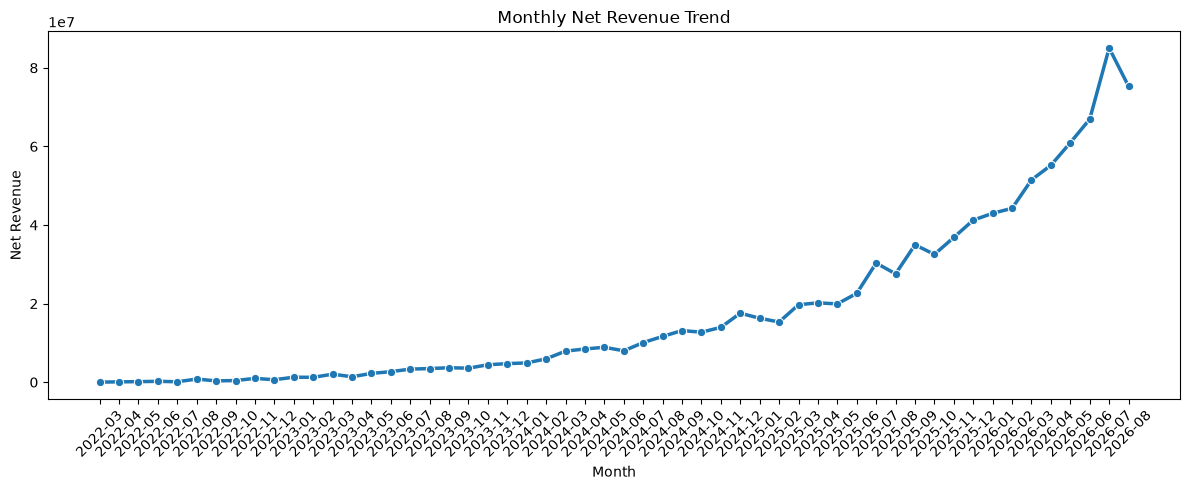

In [25]:
monthly_revenue = run_query("""
    SELECT
        strftime('%Y-%m', order_date) AS month,
        ROUND(
            SUM(
                (quantity * unit_price)
                - COALESCE(discount, 0)
            ),
            2
        ) AS net_revenue
    FROM orders
    WHERE returned = 0
    GROUP BY strftime('%Y-%m', order_date)
    ORDER BY month
""")

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_revenue,
    x="month",
    y="net_revenue",
    marker="o",
    linewidth=2.5
)

plt.title("Monthly Net Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

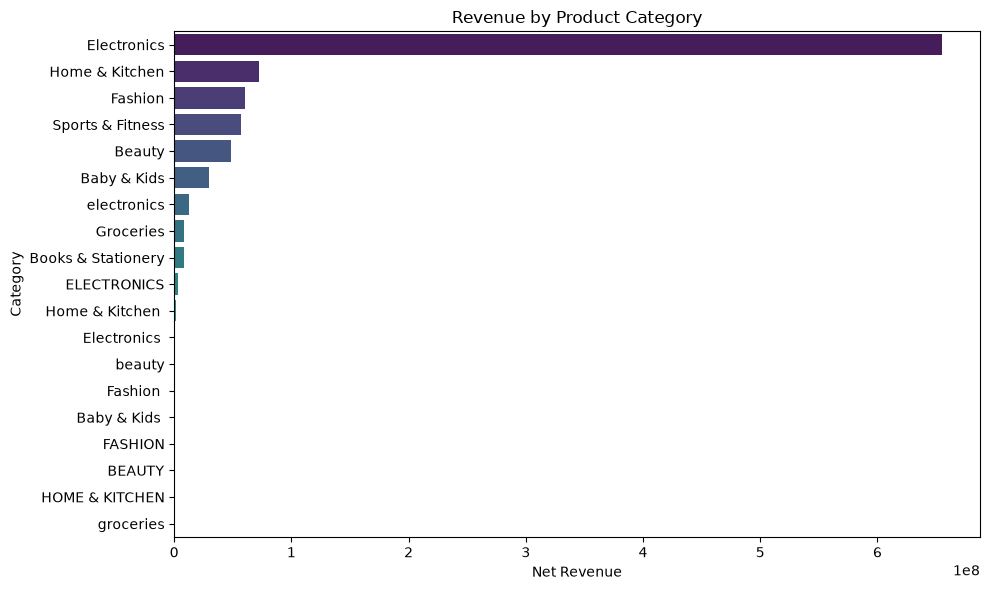

In [23]:
category_revenue = run_query("""
    SELECT
        p.category,
        ROUND(
            SUM(
                (o.quantity * o.unit_price)
                - COALESCE(o.discount, 0)
            ),
            2
        ) AS net_revenue
    FROM orders AS o
    JOIN products AS p
        ON o.product_id = p.product_id
    WHERE o.returned = 0
    GROUP BY p.category
    ORDER BY net_revenue DESC
""")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_revenue,
    x="net_revenue",
    y="category",
    hue="category",
    palette="viridis",
    legend=False
)

plt.title("Revenue by Product Category")
plt.xlabel("Net Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

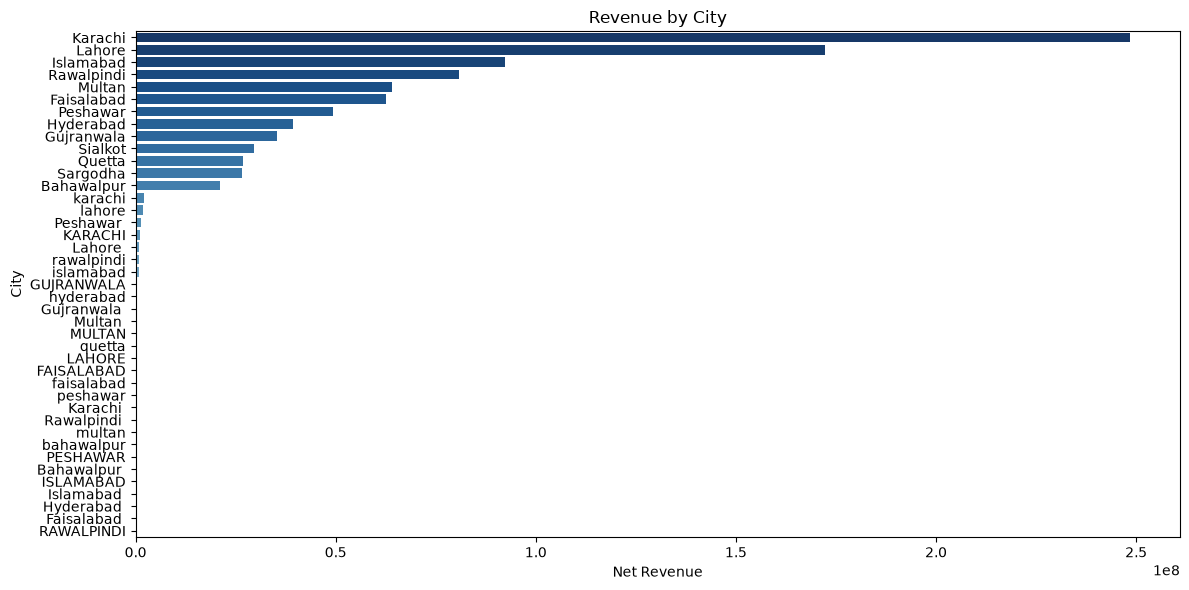

In [26]:
city_revenue = run_query("""
    SELECT
        c.city,
        ROUND(
            SUM(
                (o.quantity * o.unit_price)
                - COALESCE(o.discount, 0)
            ),
            2
        ) AS net_revenue
    FROM orders AS o
    JOIN customers AS c
        ON o.customer_id = c.customer_id
    WHERE o.returned = 0
    GROUP BY c.city
    ORDER BY net_revenue DESC
""")

plt.figure(figsize=(12, 6))

sns.barplot(
    data=city_revenue,
    x="net_revenue",
    y="city",
    hue="city",
    palette="Blues_r",
    legend=False
)

plt.title("Revenue by City")
plt.xlabel("Net Revenue")
plt.ylabel("City")
plt.tight_layout()
plt.show()



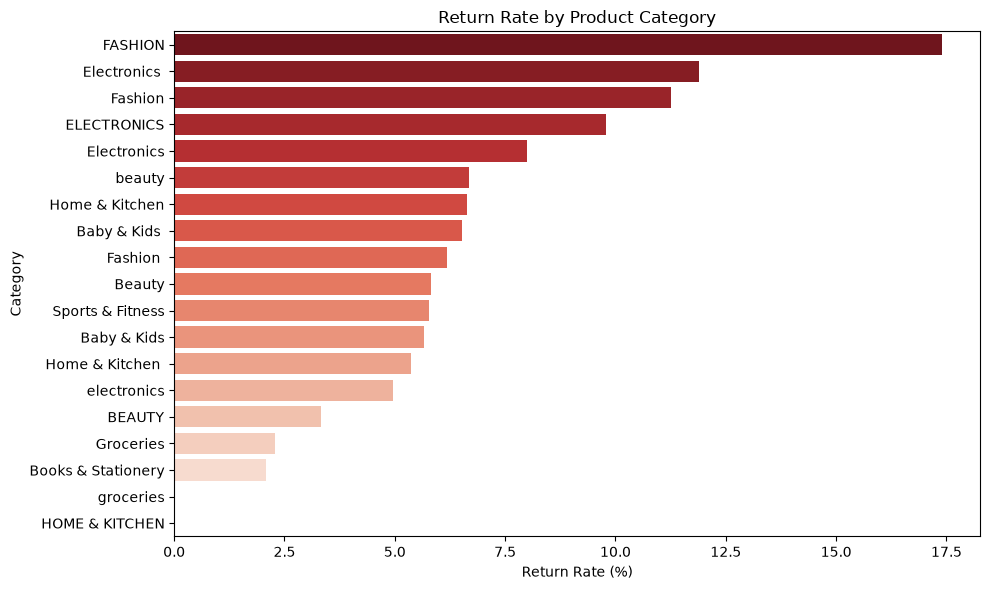

In [27]:
category_returns = run_query("""
    SELECT
        p.category,
        COUNT(o.order_id) AS total_orders,
        SUM(
            CASE
                WHEN o.returned = 1 THEN 1
                ELSE 0
            END
        ) AS returned_orders,
        ROUND(
            100.0 * SUM(
                CASE
                    WHEN o.returned = 1 THEN 1
                    ELSE 0
                END
            ) / COUNT(o.order_id),
            2
        ) AS return_rate
    FROM orders AS o
    JOIN products AS p
        ON o.product_id = p.product_id
    GROUP BY p.category
    ORDER BY return_rate DESC
""")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_returns,
    x="return_rate",
    y="category",
    hue="category",
    palette="Reds_r",
    legend=False
)

plt.title("Return Rate by Product Category")
plt.xlabel("Return Rate (%)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()



## Business Insight

### 1. Revenue Trend and Business Growth
Monthly revenue shows how consistently the business is generating sales over time. 
Periods with sustained revenue growth may indicate increasing customer demand and 
successful sales activity. This matters because management can use the trend to plan 
inventory, staffing, marketing budgets, and cash flow. A sudden decline should be 
investigated for possible changes in demand, product availability, pricing, or customer behavior.

### 2. Category Revenue Concentration
Revenue is not necessarily distributed evenly across product categories. Categories 
generating a large share of revenue are important to overall business performance 
because problems with their inventory, pricing, or supply could have a significant 
impact on total revenue. The business should therefore monitor high-revenue categories 
closely while identifying opportunities to improve weaker categories.

### 3. Geographic Revenue Opportunities
Differences in revenue across cities indicate that customer demand varies by location. 
High-revenue cities may justify greater inventory availability, targeted promotions, 
and improved delivery capacity. Lower-revenue cities may represent either weaker 
demand or an opportunity for targeted marketing and customer acquisition.

### 4. Return Rate and Operational Cost
A high return rate in a product category can reduce the value of reported sales because 
returns can create additional logistics, handling, refund, and inventory costs. 
Categories with unusually high return rates should therefore be investigated at the 
product level to identify issues such as product quality, inaccurate descriptions, 
delivery problems, or customer expectations.

### 5. Revenue vs. Return Risk
A category can generate substantial revenue while also having a high return rate. 
Looking at revenue and returns together provides a more useful business perspective 
than looking at revenue alone. Management can prioritize high-revenue categories with 
elevated returns for further investigation because reducing unnecessary returns could 
protect revenue and lower operational costs.
